<a href="https://colab.research.google.com/github/sri4022220/ML-on-Big-Data_Assignment/blob/main/Week4_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Python Spark SQL basic example") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

In [4]:
dataset = spark.read.csv('/content/titanic_synthetic_data.csv',inferSchema=True, header =True)

In [5]:
dataset.columns

['Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Sex',
 'Survived',
 'Embarked_Q',
 'Embarked_S']

In [6]:
dataset.describe().select("summary","Pclass","Age","SibSp","Parch","Fare","sex").show()

+-------+------------------+------------------+-----------------+------------------+------------------+-------------------+
|summary|            Pclass|               Age|            SibSp|             Parch|              Fare|                sex|
+-------+------------------+------------------+-----------------+------------------+------------------+-------------------+
|  count|            593802|            593802|           593802|            593802|            593802|             593802|
|   mean|1.9991327075355085|39.529762446067885|4.502260012596792| 4.501574598940388| 254.9307382728464| 0.5007628805561449|
| stddev|0.8166793231369632|23.097156994211964|2.871939837253783|2.8752309675692462|141.55911208048255|0.49999983902871753|
|    min|                 1|                 0|                0|                 0|10.000669172033327|                  0|
|    max|                 3|                79|                9|                 9| 499.9999338139367|                  1|
+-------

In [7]:
dataset.describe().select("summary","Pclass","Age","Sex","Survived").show()

+-------+------------------+------------------+-------------------+------------------+
|summary|            Pclass|               Age|                Sex|          Survived|
+-------+------------------+------------------+-------------------+------------------+
|  count|            593802|            593802|             593802|            593802|
|   mean|1.9991327075355085|39.529762446067885| 0.5007628805561449|0.5002324006992229|
| stddev|0.8166793231369632|23.097156994211964|0.49999983902871753|0.5000003670061596|
|    min|                 1|                 0|                  0|                 0|
|    max|                 3|                79|                  1|                 1|
+-------+------------------+------------------+-------------------+------------------+



In [8]:
dataset.describe().select("summary","Pclass","SibSp","Embarked_Q","Parch").show()

+-------+------------------+-----------------+-------------------+------------------+
|summary|            Pclass|            SibSp|         Embarked_Q|             Parch|
+-------+------------------+-----------------+-------------------+------------------+
|  count|            593802|           593802|             593802|            593802|
|   mean|1.9991327075355085|4.502260012596792|0.33288537256526585| 4.501574598940388|
| stddev|0.8166793231369632|2.871939837253783|0.47124630001985623|2.8752309675692462|
|    min|                 1|                0|                  0|                 0|
|    max|                 3|                9|                  1|                 9|
+-------+------------------+-----------------+-------------------+------------------+



In [9]:
from pyspark.sql.functions import col, isnan, when, count
from pyspark.sql.types import DoubleType, FloatType

# Filter columns: use isnan only for Double/Float, use isNull for all
null_checks = []
for c, dtype in dataset.dtypes:
    if dtype in ["double", "float"]:
        null_checks.append(count(when(isnan(c) | col(c).isNull(), c)).alias(c))
    else:
        null_checks.append(count(when(col(c).isNull(), c)).alias(c))

dataset.select(null_checks).show()

+------+---+-----+-----+----+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+----+---+--------+----------+----------+
|     0|  0|    0|    0|   0|  0|       0|         0|         0|
+------+---+-----+-----+----+---+--------+----------+----------+



In [10]:
import numpy as np
from pyspark.sql.functions import when
dataset=dataset.withColumn("Pclass",when(dataset.Pclass==0,np.nan).otherwise (dataset.Pclass))
dataset=dataset.withColumn("Age",when(dataset.Age==0,np.nan).otherwise(dataset.Age))
dataset=dataset.withColumn("Fare",when(dataset.Fare==0,np.nan).otherwise(dataset.Fare))
dataset=dataset.withColumn("Survived",when(dataset.Survived==0,np.nan).otherwise(dataset.Survived))
dataset=dataset.withColumn("Embarked_S",when(dataset.Embarked_S==0,np.nan).otherwise(dataset.Embarked_S))
dataset.select("Pclass","Age","Fare","sex","Survived","Embarked_S").show(6)

+------+----+------------------+---+--------+----------+
|Pclass| Age|              Fare|sex|Survived|Embarked_S|
+------+----+------------------+---+--------+----------+
|   3.0|42.0|397.00178367782024|  0|     NaN|       1.0|
|   1.0|52.0|302.12770032784186|  0|     NaN|       NaN|
|   3.0|25.0| 427.1058765283985|  1|     1.0|       NaN|
|   3.0|32.0| 326.8049924602327|  1|     NaN|       NaN|
|   1.0|40.0|17.718838497771657|  0|     NaN|       NaN|
|   1.0|20.0|402.54904361394784|  0|     NaN|       NaN|
+------+----+------------------+---+--------+----------+
only showing top 6 rows


In [11]:
from pyspark.sql.functions import col,isnan, when, count
dataset.select([count(when(isnan(c) , c)).alias(c) for c in dataset.columns]).show()

+------+----+-----+-----+----+---+--------+----------+----------+
|Pclass| Age|SibSp|Parch|Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+----+-----+-----+----+---+--------+----------+----------+
|     0|7331|    0|    0|   0|  0|  296763|         0|    395634|
+------+----+-----+-----+----+---+--------+----------+----------+



In [13]:
cols = dataset.columns
if "features" in cols: cols.remove("features")
if "Scaled_features" in cols: cols.remove("Scaled_features")
if "Fare" in cols: cols.remove("Fare")

# Drop existing vector columns to avoid duplication errors
dataset = dataset.drop("features", "Scaled_features")

from pyspark.ml.feature import VectorAssembler
# Use handleInvalid="skip" to deal with the NaNs introduced previously
assembler = VectorAssembler(inputCols=cols, outputCol="features", handleInvalid="skip")

dataset = assembler.transform(dataset)
dataset.select("features").show(truncate=False)

+----------------------------------+
|features                          |
+----------------------------------+
|[1.0,41.0,2.0,8.0,1.0,1.0,0.0,1.0]|
|[2.0,43.0,4.0,7.0,1.0,1.0,0.0,1.0]|
|[2.0,65.0,9.0,3.0,0.0,1.0,0.0,1.0]|
|[1.0,1.0,5.0,0.0,1.0,1.0,0.0,1.0] |
|[2.0,36.0,6.0,2.0,1.0,1.0,0.0,1.0]|
|[2.0,27.0,3.0,6.0,0.0,1.0,0.0,1.0]|
|[2.0,33.0,4.0,7.0,0.0,1.0,0.0,1.0]|
|[2.0,21.0,8.0,9.0,1.0,1.0,0.0,1.0]|
|[2.0,30.0,3.0,1.0,1.0,1.0,0.0,1.0]|
|[2.0,27.0,7.0,3.0,1.0,1.0,0.0,1.0]|
|[2.0,39.0,6.0,8.0,1.0,1.0,0.0,1.0]|
|[2.0,56.0,5.0,5.0,0.0,1.0,0.0,1.0]|
|[2.0,36.0,4.0,3.0,0.0,1.0,0.0,1.0]|
|[1.0,77.0,9.0,8.0,0.0,1.0,0.0,1.0]|
|[1.0,8.0,3.0,8.0,0.0,1.0,0.0,1.0] |
|[3.0,30.0,1.0,5.0,1.0,1.0,0.0,1.0]|
|[3.0,29.0,4.0,3.0,1.0,1.0,0.0,1.0]|
|[1.0,75.0,1.0,5.0,0.0,1.0,0.0,1.0]|
|[1.0,10.0,9.0,8.0,0.0,1.0,0.0,1.0]|
|[3.0,28.0,6.0,3.0,1.0,1.0,0.0,1.0]|
+----------------------------------+
only showing top 20 rows


In [14]:
from pyspark.ml.feature import StandardScaler
standardscaler=StandardScaler().setInputCol("features").setOutputCol("Scaled_features")
dataset=standardscaler.fit(dataset).transform(dataset)
dataset.select("features","Scaled_features").show(6)

+--------------------+--------------------+
|            features|     Scaled_features|
+--------------------+--------------------+
|[1.0,41.0,2.0,8.0...|[1.22521889308505...|
|[2.0,43.0,4.0,7.0...|[2.45043778617011...|
|[2.0,65.0,9.0,3.0...|[2.45043778617011...|
|[1.0,1.0,5.0,0.0,...|[1.22521889308505...|
|[2.0,36.0,6.0,2.0...|[2.45043778617011...|
|[2.0,27.0,3.0,6.0...|[2.45043778617011...|
+--------------------+--------------------+
only showing top 6 rows


In [15]:
train, test = dataset.randomSplit([0.8, 0.2], seed=12345)

In [16]:
dataset_size=float(train.select("Age").count())
numPositives=train.select("Age").where('Age == 1').count()
per_ones=(float(numPositives)/float(dataset_size))*100
numNegatives=float(dataset_size-numPositives)
print('The number of ones are {}'.format(numPositives))
print('Percentage of ones are {}'.format(per_ones))

The number of ones are 988
Percentage of ones are 1.2644457811280188


In [17]:
BalancingRatio= numNegatives/dataset_size
print('BalancingRatio = {}'.format(BalancingRatio))

BalancingRatio = 0.9873555421887198


In [18]:
train=train.withColumn("classWeights", when(train.Embarked_S == 1,BalancingRatio).otherwise(1-BalancingRatio))
train.select("classWeights").show(6)

+------------------+
|      classWeights|
+------------------+
|0.9873555421887198|
|0.9873555421887198|
|0.9873555421887198|
|0.9873555421887198|
|0.9873555421887198|
|0.9873555421887198|
+------------------+
only showing top 6 rows


In [19]:
from pyspark.ml.feature import ChiSqSelector
css = ChiSqSelector(featuresCol='Scaled_features',outputCol='Aspect',labelCol='Age',fpr=0.05)
train=css.fit(train).transform(train)
test=css.fit(test).transform(test)
test.select("Aspect").show(6,truncate=False)

+-------------------------------------------------------------------------------------------------------------+
|Aspect                                                                                                       |
+-------------------------------------------------------------------------------------------------------------+
|[1.2252188930850574,0.04381603167500822,0.0,0.3484392646345014,0.0,0.0,0.0,0.0]                              |
|[1.2252188930850574,0.04381603167500822,0.0,2.7875141170760114,0.0,0.0,0.0,0.0]                              |
|[1.2252188930850574,0.04381603167500822,0.0,2.7875141170760114,0.0,0.0,0.0,0.0]                              |
|[1.2252188930850574,0.04381603167500822,0.3480218905231536,0.0,0.0,0.0,0.0,0.0]                              |
|[1.2252188930850574,0.04381603167500822,0.3480218905231536,1.0453177939035043,0.0,0.0,0.0,0.0]               |
|[1.2252188930850574,0.04381603167500822,0.3480218905231536,2.0906355878070086,1.9999903135772787,0.0,0.

In [20]:
from pyspark.ml.classification import LogisticRegression
lr = LogisticRegression(labelCol="Survived", featuresCol="Aspect",weightCol="classWeights",maxIter=10)
model=lr.fit(train)
predict_train=model.transform(train)
predict_test=model.transform(test)
predict_test.select("Survived","prediction").show(7)

+--------+----------+
|Survived|prediction|
+--------+----------+
|     1.0|       1.0|
|     1.0|       1.0|
|     1.0|       1.0|
|     1.0|       1.0|
|     1.0|       1.0|
|     1.0|       1.0|
|     1.0|       1.0|
+--------+----------+
only showing top 7 rows


In [21]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator=BinaryClassificationEvaluator(rawPredictionCol='prediction',labelCol="Survived")
auroc = evaluator.evaluate(predict_test, {evaluator.metricName: "areaUnderROC"})
print("Area under ROC Curve: {:.4f}".format(auroc))
predict_test.select("Survived","prediction","probability").show(9)

Area under ROC Curve: 1.0000
+--------+----------+-----------+
|Survived|prediction|probability|
+--------+----------+-----------+
|     1.0|       1.0|  [0.0,1.0]|
|     1.0|       1.0|  [0.0,1.0]|
|     1.0|       1.0|  [0.0,1.0]|
|     1.0|       1.0|  [0.0,1.0]|
|     1.0|       1.0|  [0.0,1.0]|
|     1.0|       1.0|  [0.0,1.0]|
|     1.0|       1.0|  [0.0,1.0]|
|     1.0|       1.0|  [0.0,1.0]|
|     1.0|       1.0|  [0.0,1.0]|
+--------+----------+-----------+
only showing top 9 rows


In [22]:
pr = predict_test.toPandas()
TruePositive =0
FalsePositive=0
TrueNegative=0
FalseNegative=0
Postive=1.0
Negative=0.0
pos=0
Neg=0

print("Total",len(pr["Survived"]))
for lbl in range(len(pr["Survived"])):
  if  pr["prediction"][lbl]==Postive:
    pos+=1
    if pr["prediction"][lbl]==pr["Survived"][lbl]:
      TruePositive+=1
    else:
      FalsePositive+=1
  if  pr["prediction"][lbl]==Negative:
    Neg+=1
    if pr["prediction"][lbl]==pr["Survived"][lbl]:
      TrueNegative+=1
    else:
      FalseNegative+=1
#print("Total Positive & Negative predicted,  diabetes: ",pos,",Non Diabetes",Neg)
print("TruePostive",TruePositive,"FalsePostive",FalsePositive)
print("TrueNegative",TrueNegative,"FalseNegative",FalseNegative)

Total 19786
TruePostive 19786 FalsePostive 0
TrueNegative 0 FalseNegative 0


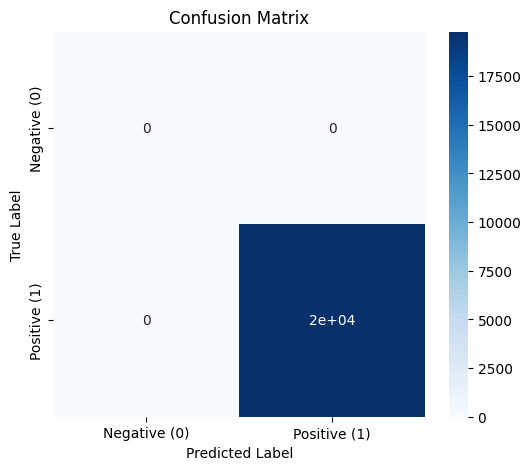

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

TN = TrueNegative
FP = FalsePositive
FN = FalseNegative
TP = TruePositive
conf_matrix = np.array([[TN, FP],
                        [FN, TP]])
labels = ["Negative (0)", "Positive (1)"]

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True,  cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [24]:
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1_score:.4f}")

Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000


In [25]:
from pyspark.sql.functions import col, when


total_count = train.count()
survived_distribution = train.groupBy('Survived').count().withColumn('percentage', (col('count') / total_count) * 100)
print("Class Distribution:")
survived_distribution.show()


count_0 = train.filter(col('Survived') == 0).count()
count_1 = train.filter(col('Survived') == 1).count()


weight_for_0 = total_count / (2.0 * count_0) if count_0 > 0 else 1.0
weight_for_1 = total_count / (2.0 * count_1) if count_1 > 0 else 1.0

train = train.withColumn("classWeights", when(col("Survived") == 1, weight_for_1).otherwise(weight_for_0))

print(f"Weight for Not Survived (0): {weight_for_0:.4f}")
print(f"Weight for Survived (1): {weight_for_1:.4f}")
train.select("Survived", "classWeights").show(5)

Class Distribution:
+--------+-----+----------+
|Survived|count|percentage|
+--------+-----+----------+
|     1.0|78137|     100.0|
+--------+-----+----------+

Weight for Not Survived (0): 1.0000
Weight for Survived (1): 0.5000
+--------+------------+
|Survived|classWeights|
+--------+------------+
|     1.0|         0.5|
|     1.0|         0.5|
|     1.0|         0.5|
|     1.0|         0.5|
|     1.0|         0.5|
+--------+------------+
only showing top 5 rows


In [26]:
# Calculate Accuracy: (TP + TN) / Total
total_samples = TP + TN + FP + FN
accuracy = (TP + TN) / total_samples if total_samples > 0 else 0

print(f"Model Evaluation Results:")
print(f"-------------------------")
print(f"Total Samples: {total_samples}")
print(f"Accuracy:      {accuracy:.4f} ({accuracy*100:.2f}%)")

Model Evaluation Results:
-------------------------
Total Samples: 19786
Accuracy:      1.0000 (100.00%)
